In [2]:
!wget https://raw.githubusercontent.com/silasfljr/STD_geoprog/refs/heads/main/IA_AGRO/Crop_recommendation.csv

--2026-04-07 19:17:50--  https://raw.githubusercontent.com/silasfljr/STD_geoprog/refs/heads/main/IA_AGRO/Crop_recommendation.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150034 (147K) [text/plain]
Saving to: ‘Crop_recommendation.csv’

Crop_recommendation 100%[===================>] 146.52K  --.-KB/s    in 0.07s   

2026-04-07 19:17:50 (2.06 MB/s) - ‘Crop_recommendation.csv’ saved [150034/150034]



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Carregar os dados
df = pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [5]:
# Separar Features e Alvo
X = df.drop('label', axis=1)
y = df['label']

In [6]:
# Dividir em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Criar e treinar o modelo Random Forest
# n_estimators=100 significa que usaremos 100 árvores de decisão
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Predições
y_pred = model.predict(X_test)

In [9]:
# Avaliação
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")

Acurácia: 99.32%


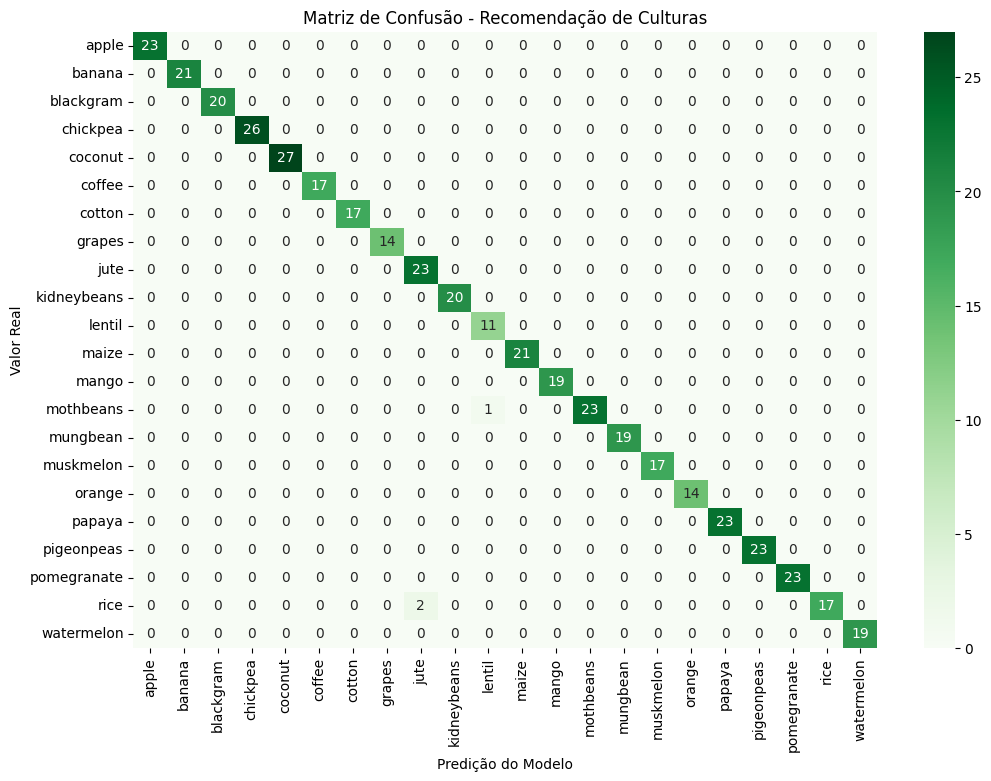

In [10]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Matriz de Confusão - Recomendação de Culturas')
plt.xlabel('Predição do Modelo')
plt.ylabel('Valor Real')
plt.show()

/tmp/ipykernel_17713/410923912.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='magma')


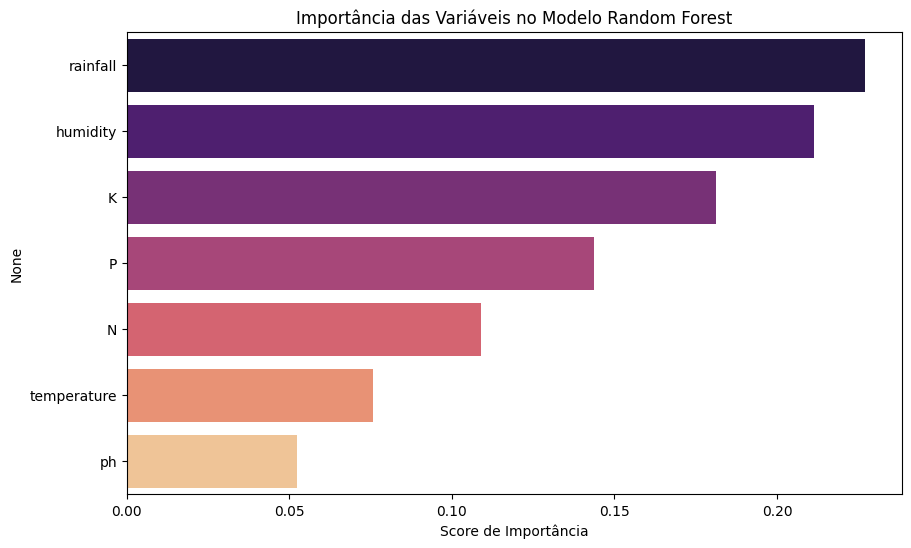

In [11]:
# Extrair importância das colunas
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.xlabel('Score de Importância')
plt.show()

In [15]:
# Solicitar inputs ao usuário
N = float(input("Digite o valor de N (Nitrogênio): "))
P = float(input("Digite o valor de P (Fósforo): "))
K = float(input("Digite o valor de K (Potássio): "))
Temp = float(input("Digite o valor da Temperatura em °C: "))
Hum = float(input("Digite o valor da Umidade do ar em %: "))
pH = float(input("Digite o valor do pH do solo: "))
Chuva = float(input("Digite o valor da Chuva em mm: "))

# Criar um DataFrame com os valores de entrada e os nomes das colunas corretos
input_data_df = pd.DataFrame([[N, P, K, Temp, Hum, pH, Chuva]],
                               columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])

# Fazer a predição com o modelo
recommendation = model.predict(input_data_df)

# Exibir a recomendação
print(f"A cultura recomendada é: {recommendation[0]}")

Digite o valor de N (Nitrogênio): 20
Digite o valor de P (Fósforo): 42
Digite o valor de K (Potássio): 30
Digite o valor da Temperatura em °C: 10
Digite o valor da Umidade do ar em %: 50
Digite o valor do pH do solo: 7
Digite o valor da Chuva em mm: 200
A cultura recomendada é: pigeonpeas
